In [ ]:
import os
import numpy as np
import pandas as pd
import librosa

In [ ]:
music_df = pd.read_csv('/content/MIREX.csv')
music_df

,energy,loudness,tempo,key,mode,time_signature,song_id,cluster,category
0,0.022155,-15.036412,120.185320,8,1,1.010972,1,Cluster 1,Boisterous
1,0.010367,-26.363678,156.605114,9,1,0.893642,2,Cluster 1,Boisterous
2,0.022840,-17.429565,105.468750,9,1,0.974649,3,Cluster 1,Boisterous
3,0.035078,-12.957283,93.963068,2,1,0.925274,4,Cluster 1,Boisterous
4,0.015994,-18.270273,103.359375,6,1,0.964630,5,Cluster 1,Boisterous
...,...,...,...,...,...,...,...,...,...
898,0.011995,-22.777634,147.656250,4,1,0.931142,899,Cluster 5,Volatile
899,0.016072,-14.258656,143.554688,2,1,0.957746,900,Cluster 5,Volatile
900,0.031603,-13.698313,97.508844,11,1,0.934561,901,Cluster 5,Volatile
901,0.013646,-18.903427,97.508844,6,1,0.953834,902,Cluster 5,Volatile


In [ ]:
music_df['cluster'] = music_df['cluster'].apply(lambda x: int(x.split()[1]))
music_df

,energy,loudness,tempo,key,mode,time_signature,song_id,cluster,category
0,0.022155,-15.036412,120.185320,8,1,1.010972,1,1,Boisterous
1,0.010367,-26.363678,156.605114,9,1,0.893642,2,1,Boisterous
2,0.022840,-17.429565,105.468750,9,1,0.974649,3,1,Boisterous
3,0.035078,-12.957283,93.963068,2,1,0.925274,4,1,Boisterous
4,0.015994,-18.270273,103.359375,6,1,0.964630,5,1,Boisterous
...,...,...,...,...,...,...,...,...,...
898,0.011995,-22.777634,147.656250,4,1,0.931142,899,5,Volatile
899,0.016072,-14.258656,143.554688,2,1,0.957746,900,5,Volatile
900,0.031603,-13.698313,97.508844,11,1,0.934561,901,5,Volatile
901,0.013646,-18.903427,97.508844,6,1,0.953834,902,5,Volatile


In [ ]:
music_df.columns

Index(['energy', 'loudness', 'tempo', 'key', 'mode', 'time_signature',
       'song_id', 'cluster', 'category'],
      dtype='object')

In [ ]:
music_df = music_df[['song_id', 'energy', 'loudness', 'tempo', 'key', 'mode', 'time_signature', 'cluster', 'category']]

In [ ]:
music_df.to_csv('MIREX.csv', index=False)

# data load

In [ ]:
from google.colab import drive
import zipfile

# 파일 경로
zip_file_path = '/content/drive/MyDrive/start-10/MIREX/MIREX-like_mood.zip'

# 압축 해제
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
  zip_ref.extractall('/content/MIREX')

print(f"{zip_file_path} 압축 해제 완료!")

/content/drive/MyDrive/start-10/MIREX/MIREX-like_mood.zip 압축 해제 완료!


In [ ]:
# 오디오 파일 디렉토리 경로
audio_dir = '/content/MIREX/dataset/Audio'

# 주석 파일 로드
cluster_file_path = '/content/MIREX/dataset/clusters.txt'
cluster_df = pd.read_csv(cluster_file_path, header=None, names=['cluster'])
category_file_path = '/content/MIREX/dataset/categories.txt'
category_df = pd.read_csv(category_file_path, header=None, names=['category'])

In [ ]:
mood_df = pd.concat([cluster_df['cluster'], category_df['category']], axis=1)
mood_df

,cluster,category
0,Cluster 1,Boisterous
1,Cluster 1,Boisterous
2,Cluster 1,Boisterous
3,Cluster 1,Boisterous
4,Cluster 1,Boisterous
...,...,...
898,Cluster 5,Volatile
899,Cluster 5,Volatile
900,Cluster 5,Volatile
901,Cluster 5,Volatile


# audio feaures extraction

In [ ]:
#!pip install pymusickit
from pymusickit.key_finder import KeyFinder
import librosa

def extract_audio_features(file_path):
    # 오디오 파일 로드
    y, sr = librosa.load(file_path, sr=None)

    # 에너지 계산
    energy = np.sum(y**2) / len(y)

    # 음량(Loudness) 계산
    S = np.abs(librosa.stft(y))
    loudness = np.mean(librosa.amplitude_to_db(S))

    # 템포(Tempo) 추정
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)

    # 키(Key) 및 모드(Mode) 추정
    song = KeyFinder(file_path)
    key = song.key
    mode = song.mode  # 1: Major, 0: Minor

    # 박자(Time Signature) 추정
    onset_env = librosa.onset.onset_strength(y=y, sr=sr)
    times = librosa.times_like(onset_env, sr=sr)
    tempo, beats = librosa.beat.beat_track(onset_envelope=onset_env, sr=sr)
    beat_times = librosa.frames_to_time(beats, sr=sr)
    time_signature = len(beat_times) / (times[-1] / 60) / tempo

    return {
        'energy': energy,
        'loudness': loudness,
        'tempo': tempo,
        'key': key,
        'mode': mode,
        'time_signature': time_signature
    }

In [ ]:
features = []

for idx, row in mood_df.head(5).iterrows():
    song_id = idx+1
    file_path = os.path.join(audio_dir, f'{song_id:03d}.mp3')

    if os.path.exists(file_path):
        audio_features = extract_audio_features(file_path)
        audio_features.update({
            'song_id': song_id,
            'cluster': row['cluster'],
            'category': row['category']
        })
        features.append(audio_features)
    else:
        print(f'파일 {file_path}을 찾을 수 없습니다.')

# 데이터프레임 생성
mirex_df_re = pd.DataFrame(features)

AttributeError: 'KeyFinder' object has no attribute 'key'

In [ ]:
mirex_df

NameError: name 'mirex_df' is not defined

In [ ]:
mirex_df['tempo'] = mirex_df['tempo'].apply(lambda x: x[0] if len(x) == 1 else x)
mirex_df['time_signature'] = mirex_df['time_signature'].apply(lambda x: x[0] if len(x) == 1 else x)

In [ ]:
mirex_df.to_csv('MIREX.csv', index=False)

array([[<Axes: title={'center': 'energy'}>,
        <Axes: title={'center': 'loudness'}>,
        <Axes: title={'center': 'tempo'}>],
       [<Axes: title={'center': 'key'}>,
        <Axes: title={'center': 'mode'}>,
        <Axes: title={'center': 'time_signature'}>],
       [<Axes: title={'center': 'song_id'}>,
        <Axes: title={'center': 'valence_mean'}>,
        <Axes: title={'center': 'arousal_mean'}>]], dtype=object)

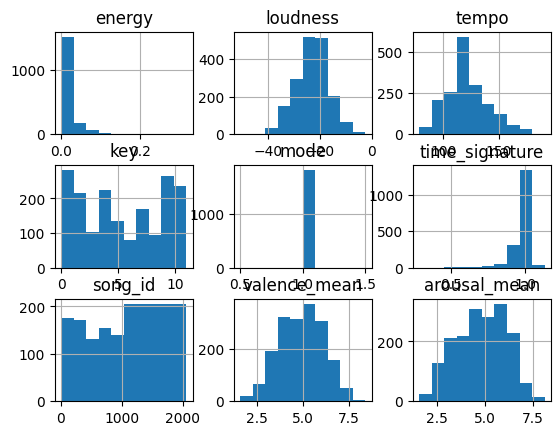

In [ ]:
mirex_df.hist()

In [ ]:
music_df

,energy,loudness,tempo,key,mode,time_signature,song_id,valence_mean,arousal_mean
0,0.012146,-21.465645,139.674831,9,1,1.001031,2.0,3.10,3.00
1,0.017426,-25.533651,95.703125,4,1,0.988654,3.0,3.50,3.30
2,0.039658,-18.046253,112.347147,9,1,1.008252,4.0,5.70,5.50
3,0.024600,-20.400837,123.046875,11,1,1.018051,5.0,4.40,5.30
4,0.074468,-19.637709,120.185320,4,1,0.997166,7.0,5.80,6.40
...,...,...,...,...,...,...,...,...,...
1797,0.015683,-29.476341,178.205819,11,1,0.972539,2054.0,5.40,3.60
1798,0.030940,-15.287614,123.046875,9,1,1.004990,2055.0,5.00,5.20
1799,0.008828,-25.813923,99.384014,4,1,0.973944,2056.0,5.00,4.60
1800,0.033607,-13.712579,126.048018,11,1,0.990992,2057.0,3.17,6.83


# Classification Model

## 신경망

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

In [ ]:
X = music_df[['energy', 'loudness', 'tempo', 'key', 'time_signature']].values
y = music_df[['cluster']].values

encoder = OneHotEncoder(categories='auto', sparse_output=False)
y_encoded = encoder.fit_transform(y.reshape(-1, 1))

# train - val split
X_train, X_val, y_train, y_val = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# tensor
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

# dataloader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [ ]:
class MultiClassificationModel(nn.Module):
    def __init__(self, input_dim, output_dim=5):
        super().__init__()

        self.model = nn.Sequential(
            nn.BatchNorm1d(input_dim),
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.BatchNorm1d(128),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.BatchNorm1d(64),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.BatchNorm1d(32),
            nn.Linear(32, output_dim)
        )

    def forward(self, x):
        return self.model(x)

def loss_fn(y_pred, y_true):
    ce = nn.CrossEntropyLoss()
    loss = ce(y_pred, y_true)
    return loss

In [ ]:
input_dim = X_train_tensor.shape[1]
model = MultiClassificationModel(input_dim)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 학습 파라미터 설정
epochs = 30
train_loss = []
val_loss = []

# 훈련 루프
model.train()
for epoch in range(epochs):
    total_train_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
    avg_train_loss = total_train_loss / len(train_loader)

    # 검증 루프
    model.eval()
    with torch.no_grad():
        total_val_loss = 0
        for X_batch, y_batch in val_loader:
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_val_loss += loss.item()
        avg_val_loss = total_val_loss / len(val_loader)

    print(f'Epoch [{epoch+1}/{epochs}], '
          f'Train Loss: {avg_train_loss:.4f}, '
          f'Val Loss: {avg_val_loss:.4f}')

    train_loss.append(avg_train_loss)
    val_loss.append(avg_val_loss)

Epoch [1/30], Train Loss: 1.7161, Val Loss: 1.6245
Epoch [2/30], Train Loss: 1.6031, Val Loss: 1.6020
Epoch [3/30], Train Loss: 1.5664, Val Loss: 1.5914
Epoch [4/30], Train Loss: 1.5477, Val Loss: 1.5987
Epoch [5/30], Train Loss: 1.5258, Val Loss: 1.6023
Epoch [6/30], Train Loss: 1.5233, Val Loss: 1.6022
Epoch [7/30], Train Loss: 1.5093, Val Loss: 1.5987
Epoch [8/30], Train Loss: 1.4934, Val Loss: 1.5991
Epoch [9/30], Train Loss: 1.4850, Val Loss: 1.6010
Epoch [10/30], Train Loss: 1.4920, Val Loss: 1.6137
Epoch [11/30], Train Loss: 1.4816, Val Loss: 1.6015
Epoch [12/30], Train Loss: 1.4761, Val Loss: 1.6001
Epoch [13/30], Train Loss: 1.4592, Val Loss: 1.5980
Epoch [14/30], Train Loss: 1.4466, Val Loss: 1.6045
Epoch [15/30], Train Loss: 1.4462, Val Loss: 1.6045
Epoch [16/30], Train Loss: 1.4329, Val Loss: 1.6123
Epoch [17/30], Train Loss: 1.4341, Val Loss: 1.6136
Epoch [18/30], Train Loss: 1.4250, Val Loss: 1.6133
Epoch [19/30], Train Loss: 1.4164, Val Loss: 1.6136
Epoch [20/30], Train 

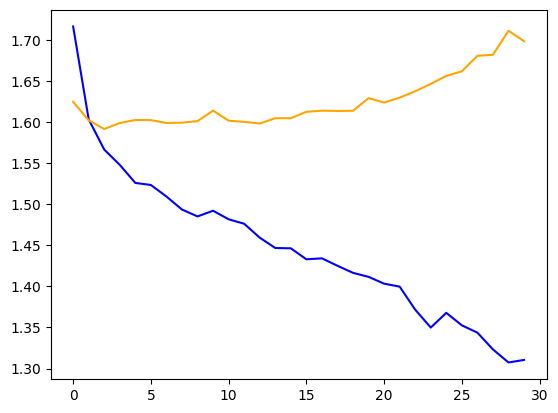

In [ ]:
import matplotlib.pyplot as plt
plt.plot(train_loss, label='Train Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='orange')

In [ ]:
# 테스트 데이터 예측
model.eval()
with torch.no_grad():
    y_pred_tensor = model(X_val_tensor)
    y_pred = y_pred_tensor.numpy()

# 평가 지표 계산
from sklearn.metrics import mean_squared_error, r2_score
y_test = y_val_tensor.numpy()
mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred, multioutput='raw_values')

print(f'MSE for each output: {mse}')
print(f'RMSE: {rmse}')
print(f'R^2 Score: {r2}')

MSE for each output: [0.9785938  0.95432955]
RMSE: [0.98923904 0.9768979 ]
R^2 Score: [0.26991218 0.35459483]


In [ ]:
# 평균 계산
dummy_pred = torch.mean(y_train_tensor, dim=0).unsqueeze(0).expand(y_val_tensor.size(0), -1).cpu().numpy()

# 평가 지표 계산
dummy_mse = mean_squared_error(y_test, dummy_pred, multioutput='raw_values')
dummy_rmse = np.sqrt(dummy_mse)
dummy_r2 = r2_score(y_test, dummy_pred, multioutput='raw_values')

print(f'Dummy RMSE: {dummy_rmse}')
print(f'Dummy R^2 Score: {dummy_r2}')

Dummy RMSE: [1.1621872 1.2190019]
Dummy R^2 Score: [-0.00768507 -0.00494623]


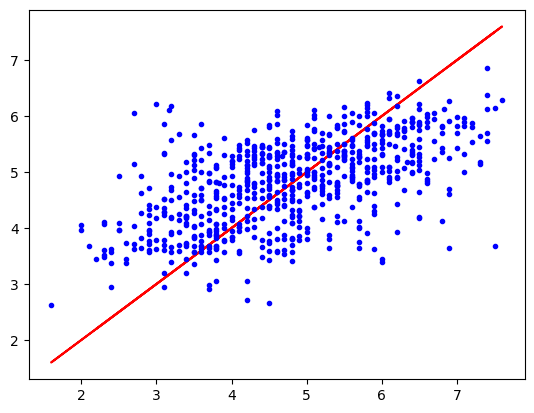

In [ ]:
import matplotlib.pyplot as plt

plt.plot(y_test, y_test, 'r-')
plt.plot(y_test, y_pred, 'b.')